<a href="https://colab.research.google.com/github/Diegoggonfer/Modelos/blob/main/Modelo_DTIP_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Carga de los Datos


In [ ]:
import pandas as pd

# Carga de datos
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Modelos DTI/archivos/all_smiles_data.csv')
blindtest_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Modelos DTI/test/tox24_challenge_test.csv')

print("Nombres de las columnas:")
print(data.columns.tolist())

print("\nDimensiones del dataset:")
print(data.shape)

# Mostrar el header del dataframe
display(data.head())



Nombres de las columnas:
['dataset', 'Chemical', 'activity', 'pubchem_smiles', 'alogps_smiles', 'pubchem_smiles_cleaned', 'alogps_smiles_cleaned', 'pubchem_smiles_no_iso_atoms', 'pubchem_smiles_no_salts', 'pubchem_smiles_no_iso_atoms_and_dup', 'alogps_smiles_no_salts']

Dimensiones del dataset:
(1512, 11)


,dataset,Chemical,activity,pubchem_smiles,alogps_smiles,pubchem_smiles_cleaned,alogps_smiles_cleaned,pubchem_smiles_no_iso_atoms,pubchem_smiles_no_salts,pubchem_smiles_no_iso_atoms_and_dup,alogps_smiles_no_salts
0,leaderboard,(-)-alpha-Pinene,11.695433,CC1=CCC2CC1C2(C)C,CC1=CC[C@H]2C[C@@H]1C2(C)C,CC1=CCC2CC1C2(C)C,CC1=CC[C@H]2C[C@@H]1C2(C)C,CC1=CCC2CC1C2(C)C,CC1=CCC2CC1C2(C)C,CC1=CCC2CC1C2(C)C,CC1=CC[C@H]2C[C@@H]1C2(C)C
1,training,(-)-beta-Pinene,12.330696,CC1(C2CCC(=C)C1C2)C,CC1(C)[C@@H]2C[C@H]1C(=C)CC2,C=C1CCC2CC1C2(C)C,C=C1CC[C@H]2C[C@@H]1C2(C)C,C=C1CCC2CC1C2(C)C,C=C1CCC2CC1C2(C)C,C=C1CCC2CC1C2(C)C,C=C1CC[C@H]2C[C@@H]1C2(C)C
2,training,(+-)-Diclofop-methyl,94.148631,CC(C(=O)OC)OC1=CC=C(C=C1)OC2=C(C=C(C=C2)Cl)Cl,COC(=O)C(C)OC1=CC=C(OC2=CC=C(Cl)C=C2Cl)C=C1,COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1,COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1,COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1,COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1,COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1,COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1
3,blind test,(+/-)-2-(4-Chloro-2-methylphenoxy)propionic acid,NaN,CC1=C(C=CC(=C1)Cl)OC(C)C(=O)O,CC(OC1=C(C)C=C(Cl)C=C1)C(O)=O,Cc1cc(Cl)ccc1OC(C)C(=O)O,Cc1cc(Cl)ccc1OC(C)C(=O)O,Cc1cc(Cl)ccc1OC(C)C(=O)O,Cc1cc(Cl)ccc1OC(C)C(=O)O,Cc1cc(Cl)ccc1OC(C)C(=O)O,Cc1cc(Cl)ccc1OC(C)C(=O)O
4,training,"(+/-)-2,3-Dihydroxypropyl tetradecanoate",38.112362,CCCCCCCCCCCCCC(=O)OCC(CO)O,CCCCCCCCCCCCCC(=O)OCC(O)CO,CCCCCCCCCCCCCC(=O)OCC(O)CO,CCCCCCCCCCCCCC(=O)OCC(O)CO,CCCCCCCCCCCCCC(=O)OCC(O)CO,CCCCCCCCCCCCCC(=O)OCC(O)CO,CCCCCCCCCCCCCC(=O)OCC(O)CO,CCCCCCCCCCCCCC(=O)OCC(O)CO


### Preparación y Limpieza de Datos

Se realiza la preparación inicial de los datos. Se separa el conjunto de 'blind test' del dataset principal y se eliminan las filas con valores Nulos en la columna 'activity' para los conjuntos de entrenamiento y 'leaderboard'.

In [ ]:
print("\nPreparación de los datos:")

# Separar los datos de 'blind test' del dataset principal (all_smiles_data)
# antes de eliminar las filas con NaNs en 'activity'.
# Estos son los compuestos de all_smiles_data que tienen 'dataset' == 'blind test'.
# Estos compuestos no tienen 'activity' definida en all_smiles_data, por diseño.
main_dataset_blind_test_data_original = data[data['dataset'] == 'blind test'].copy()
print(f"Dimensiones del conjunto 'blind test' (del dataset principal) capturado: {main_dataset_blind_test_data_original.shape}")

# Ahora, filtrar el dataset 'data' para el entrenamiento y leaderboard
data_for_training_leaderboard = data[data['dataset'] != 'blind test'].copy()

# Eliminar filas sin variable objetivo 'activity' del conjunto para entrenamiento/leaderboard
original_rows_count_tl = data_for_training_leaderboard.shape[0]
data_for_training_leaderboard.dropna(axis=0, subset=['activity'], inplace=True)
print(f"Filas para entrenamiento/leaderboard después de eliminar NaNs en Activity: {data_for_training_leaderboard.shape[0]} (original: {original_rows_count_tl})")

# Separar la variable objetivo 'activity' del resto de las características para entrenamiento/leaderboard
y = data_for_training_leaderboard['activity']
X = data_for_training_leaderboard.drop(['activity'], axis=1)

print(f"Dimensiones de X (features para entrenamiento/leaderboard): {X.shape}")
print(f"Dimensiones de y (target para entrenamiento/leaderboard): {y.shape}")


Preparación de los datos:
Dimensiones del conjunto 'blind test' (del dataset principal) capturado: (300, 11)
Filas para entrenamiento/leaderboard después de eliminar NaNs en Activity: 1212 (original: 1212)
Dimensiones de X (features para entrenamiento/leaderboard): (1212, 10)
Dimensiones de y (target para entrenamiento/leaderboard): (1212,)


### División de Datos en Conjuntos de Entrenamiento y Evaluación

Se divide los datos preparados en conjuntos específicos para entrenamiento, 'leaderboard' (evaluación intermedia) y el conjunto final de 'blind test'

In [ ]:
# Dividir los datos en conjuntos de entrenamiento, leaderboard
training_data = X[X['dataset'] == 'training']
training_target = y[X['dataset'] == 'training']

leaderboard_data = X[X['dataset'] == 'leaderboard']
leaderboard_target = y[X['dataset'] == 'leaderboard']

# La variable 'main_dataset_blind_test_data_original' ya fue capturada en el paso anterior.
# Ahora la preparamos eliminando la columna 'dataset'.
main_dataset_blind_test_data = main_dataset_blind_test_data_original.drop('dataset', axis=1).copy()

# Eliminar la columna 'dataset' de los conjuntos de características
training_data = training_data.drop('dataset', axis=1)
leaderboard_data = leaderboard_data.drop('dataset', axis=1)
# La columna 'dataset' de main_dataset_blind_test_data ya fue eliminada arriba.

print(f"\nDimensiones del conjunto de entrenamiento: {training_data.shape}, target: {training_target.shape}")
print(f"Dimensiones del conjunto de leaderboard (test): {leaderboard_data.shape}, target: {leaderboard_target.shape}")
print(f"Dimensiones del conjunto 'blind test' (del dataset principal): {main_dataset_blind_test_data.shape}")
print(f"Dimensiones del blindtest_data inicial (para uso posterior): {blindtest_data.shape}")


Dimensiones del conjunto de entrenamiento: (1012, 9), target: (1012,)
Dimensiones del conjunto de leaderboard (test): (200, 9), target: (200,)
Dimensiones del conjunto 'blind test' (del dataset principal): (300, 10)
Dimensiones del blindtest_data inicial (para uso posterior): (300, 2)


### Instalación e Importación de Bibliotecas


In [ ]:
print("Instalando bibliotecas necesarias: RDKit, XGBoost, CatBoost...")
!pip install rdkit xgboost catboost scikit-learn numpy pandas --quiet

# Importar bibliotecas
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator # Importar MorganGenerator
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor

print("Bibliotecas instaladas e importadas.")

Instalando bibliotecas necesarias: RDKit, XGBoost, CatBoost...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
Bibliotecas instaladas e importadas.


### Generación de Características Moleculares (Morgan Fingerprints)

Se define una función para generar Morgan Fingerprints a partir de cadenas SMILES

In [ ]:
# Función para generar Morgan Fingerprints desde una cadena SMILES
def get_morgan_fingerprints(smiles, radius=2, n_bits=2048):
    if pd.isna(smiles):
        return None # Indica fallo explícito
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None # Indica fallo explícito
    try:
        Chem.SanitizeMol(mol)
        # Usar MorganGenerator en lugar de AllChem.GetMorganFingerprintAsBitVect
        morgan_gen = GetMorganGenerator(radius=radius, fpSize=n_bits)
        fp = morgan_gen.GetFingerprint(mol)
        return np.array(list(fp.ToBitString())).astype(int)
    except Exception:
        # No imprimir el warning aquí para evitar saturar la salida
        return None # Indica fallo explícito

print("\nGenerando características moleculares (Morgan Fingerprints) con RDKit...")

# Asegurar que los DataFrames y Series estén reindexados para una correcta alineación
training_data_reindexed = training_data.reset_index(drop=True)
leaderboard_data_reindexed = leaderboard_data.reset_index(drop=True)
training_target_aligned = training_target.reset_index(drop=True)
leaderboard_target_aligned = leaderboard_target.reset_index(drop=True)

# Generar fingerprints para los datos de entrenamiento y filtrar los fallidos
successful_training_indices = []
successful_training_features = []
for i, smiles in enumerate(training_data_reindexed['pubchem_smiles_cleaned']):
    fp = get_morgan_fingerprints(smiles)
    if fp is not None:
        successful_training_indices.append(i)
        successful_training_features.append(fp)

training_features_rdkit = pd.DataFrame(successful_training_features)
training_target_filtered = training_target_aligned.iloc[successful_training_indices]

# Generar fingerprints para los datos de leaderboard y filtrar los fallidos
successful_leaderboard_indices = []
successful_leaderboard_features = []
for i, smiles in enumerate(leaderboard_data_reindexed['pubchem_smiles_cleaned']):
    fp = get_morgan_fingerprints(smiles)
    if fp is not None:
        successful_leaderboard_indices.append(i)
        successful_leaderboard_features.append(fp)

leaderboard_features_rdkit = pd.DataFrame(successful_leaderboard_features)
leaderboard_target_filtered = leaderboard_target_aligned.iloc[successful_leaderboard_indices]

print(f"Dimensiones de las características de entrenamiento (RDKit) después de filtrar: {training_features_rdkit.shape}")
print(f"Dimensiones de las características de leaderboard (RDKit) después de filtrar: {leaderboard_features_rdkit.shape}")
print(f"SMILES descartados en entrenamiento: {len(training_data_reindexed) - training_features_rdkit.shape[0]}")
print(f"SMILES descartados en leaderboard: {len(leaderboard_data_reindexed) - leaderboard_features_rdkit.shape[0]}")


Generando características moleculares (Morgan Fingerprints) con RDKit...
Dimensiones de las características de entrenamiento (RDKit) después de filtrar: (1012, 2048)
Dimensiones de las características de leaderboard (RDKit) después de filtrar: (200, 2048)
SMILES descartados en entrenamiento: 0
SMILES descartados en leaderboard: 0


### Entrenamiento y Evaluación del Modelo XGBoost

Entrenamos un modelo de regresión XGBoost utilizando las características moleculares generadas. Evaluamos su rendimiento en el conjunto de 'leaderboard' utilizando métricas MAE, RMSE y R2.

In [ ]:
print("\nEntrenando y evaluando modelo XGBoost...")

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, tree_method='hist')
xgb_model.fit(training_features_rdkit, training_target_filtered) # Usar el target filtrado
xgb_predictions = xgb_model.predict(leaderboard_features_rdkit)

xgb_mae = mean_absolute_error(leaderboard_target_filtered, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(leaderboard_target_filtered, xgb_predictions))
xgb_r2 = r2_score(leaderboard_target_filtered, xgb_predictions)

# Calcular RMSE como porcentaje
mean_activity_leaderboard = leaderboard_target_filtered.mean()
xgb_rmse_percentage = (xgb_rmse / mean_activity_leaderboard) * 100 if mean_activity_leaderboard != 0 else 0

print(f"Resultados XGBoost:\n  MAE: {xgb_mae:.4f}\n  RMSE: {xgb_rmse:.4f}\n  RMSE (%): {xgb_rmse_percentage:.2f}%\n  R2: {xgb_r2:.4f}")


Entrenando y evaluando modelo XGBoost...
Resultados XGBoost:
  MAE: 18.9479
  RMSE: 25.2338
  RMSE (%): 75.74%
  R2: 0.4217


### Entrenamiento y Evaluación del Modelo CatBoost

Entrenamos un modelo de regresión CatBoost. Su rendimiento se evalúa en el conjunto de 'leaderboard' con las mismas métricas.

In [ ]:
# --- Modelo CatBoost ---
print("\nEntrenando y evaluando modelo CatBoost...")

# CatBoost es robusto con características categóricas, pero aquí usamos fingerprints numéricos
cat_model = CatBoostRegressor(iterations=100,
                              learning_rate=0.1,
                              depth=6,
                              loss_function='RMSE',
                              verbose=0, # Suprimir la salida de entrenamiento
                              random_seed=42)
cat_model.fit(training_features_rdkit, training_target_filtered) # Usar el target filtrado
cat_predictions = cat_model.predict(leaderboard_features_rdkit)

cat_mae = mean_absolute_error(leaderboard_target_filtered, cat_predictions)
cat_rmse = np.sqrt(mean_squared_error(leaderboard_target_filtered, cat_predictions))
cat_r2 = r2_score(leaderboard_target_filtered, cat_predictions)

# Calcular RMSE como porcentaje
mean_activity_leaderboard = leaderboard_target_filtered.mean()
cat_rmse_percentage = (cat_rmse / mean_activity_leaderboard) * 100 if mean_activity_leaderboard != 0 else 0

print(f"Resultados CatBoost:\n  MAE: {cat_mae:.4f}\n  RMSE: {cat_rmse:.4f}\n  RMSE (%): {cat_rmse_percentage:.2f}%\n  R2: {cat_r2:.4f}")


Entrenando y evaluando modelo CatBoost...
Resultados CatBoost:
  MAE: 19.7105
  RMSE: 25.6114
  RMSE (%): 76.87%
  R2: 0.4042


### Predicción para el conjunto 'blind test'

Se prepara el conjunto `blind test` para la predicción, rellenando los valores de `activity` con los del `blindtest_data` original donde haya coincidencias de SMILES y luego generando las huellas moleculares.

In [ ]:
# 1. Crear un mapeo de SMILES a TTR binding activity desde blindtest_data
smiles_to_activity_map = blindtest_data.set_index('SMILES')['TTR binding activity'].to_dict()

# 2. Rellenar 'activity' en main_dataset_blind_test_data
# Utilizar 'alogps_smiles' de main_dataset_blind_test_data para la coincidencia
main_dataset_blind_test_data['activity_from_blindtest_csv'] = main_dataset_blind_test_data['alogps_smiles'].map(smiles_to_activity_map)

print("Valores de 'activity_from_blindtest_csv' rellenados en main_dataset_blind_test_data:")
display(main_dataset_blind_test_data[['alogps_smiles', 'activity_from_blindtest_csv']].head())

Valores de 'activity_from_blindtest_csv' rellenados en main_dataset_blind_test_data:


,alogps_smiles,activity_from_blindtest_csv
3,CC(OC1=C(C)C=C(Cl)C=C1)C(O)=O,70.6
8,CC(C)=CCC/C(/C)=C/CO,49.0
9,CC(CN1C[C@H](C)O[C@H](C)C1)CC2=CC=C(C=C2)C(C)(C)C,40.4
18,COC1=CC=C(/C=C/C)C=C1,25.4
21,CC(C)=CCC/C(/C)=C\CO,84.9


#### Generación de Fingerprints para el conjunto 'blind test'

Se generan las Morgan Fingerprints para el conjunto `blind test` utilizando la columna `pubchem_smiles_cleaned`, ya que fue la utilizada durante el entrenamiento.

In [ ]:
# Asegurar que el DataFrame de 'blind test' esté reindexado para una correcta alineación
blind_test_data_reindexed = main_dataset_blind_test_data.reset_index(drop=True)

# Generar fingerprints para los datos de 'blind test' y filtrar los fallidos
successful_blind_test_indices = []
successful_blind_test_features = []
for i, smiles in enumerate(blind_test_data_reindexed['pubchem_smiles_cleaned']):
    fp = get_morgan_fingerprints(smiles)
    if fp is not None:
        successful_blind_test_indices.append(i)
        successful_blind_test_features.append(fp)

blind_test_features_rdkit = pd.DataFrame(successful_blind_test_features)

print(f"Dimensiones de las características de 'blind test' (RDKit): {blind_test_features_rdkit.shape}")
print(f"SMILES descartados en 'blind test': {len(blind_test_data_reindexed) - blind_test_features_rdkit.shape[0]}")

Dimensiones de las características de 'blind test' (RDKit): (300, 2048)
SMILES descartados en 'blind test': 0


#### Realizar Predicciones con los Modelos Entrenados



In [ ]:
# Predicciones con XGBoost
blind_test_xgb_predictions = xgb_model.predict(blind_test_features_rdkit)

# Predicciones con CatBoost
blind_test_cat_predictions = cat_model.predict(blind_test_features_rdkit)

# Crear un DataFrame para mostrar los resultados
blind_test_results = blind_test_data_reindexed.iloc[successful_blind_test_indices].copy()
blind_test_results['Predicted_Activity_XGBoost'] = blind_test_xgb_predictions
blind_test_results['Predicted_Activity_CatBoost'] = blind_test_cat_predictions

print("Predicciones para el conjunto 'blind test':")
display(blind_test_results[['Chemical', 'alogps_smiles', 'activity_from_blindtest_csv', 'Predicted_Activity_XGBoost', 'Predicted_Activity_CatBoost']].head())

Predicciones para el conjunto 'blind test':


,Chemical,alogps_smiles,activity_from_blindtest_csv,Predicted_Activity_XGBoost,Predicted_Activity_CatBoost
0,(+/-)-2-(4-Chloro-2-methylphenoxy)propionic acid,CC(OC1=C(C)C=C(Cl)C=C1)C(O)=O,70.6,62.433758,52.216858
1,"(2E)-3,7-Dimethyl-2,6-octadien-1-ol",CC(C)=CCC/C(/C)=C/CO,49.0,75.062294,41.438560
2,"(2R,6S)-Fenpropimorph",CC(CN1C[C@H](C)O[C@H](C)C1)CC2=CC=C(C=C2)C(C)(C)C,40.4,-5.485579,22.083551
3,(E)-Anethole,COC1=CC=C(/C=C/C)C=C1,25.4,39.085392,44.979337
4,(Z)-Nerol,CC(C)=CCC/C(/C)=C\CO,84.9,75.062294,41.438560


#### Comparación y Análisis de Predicciones


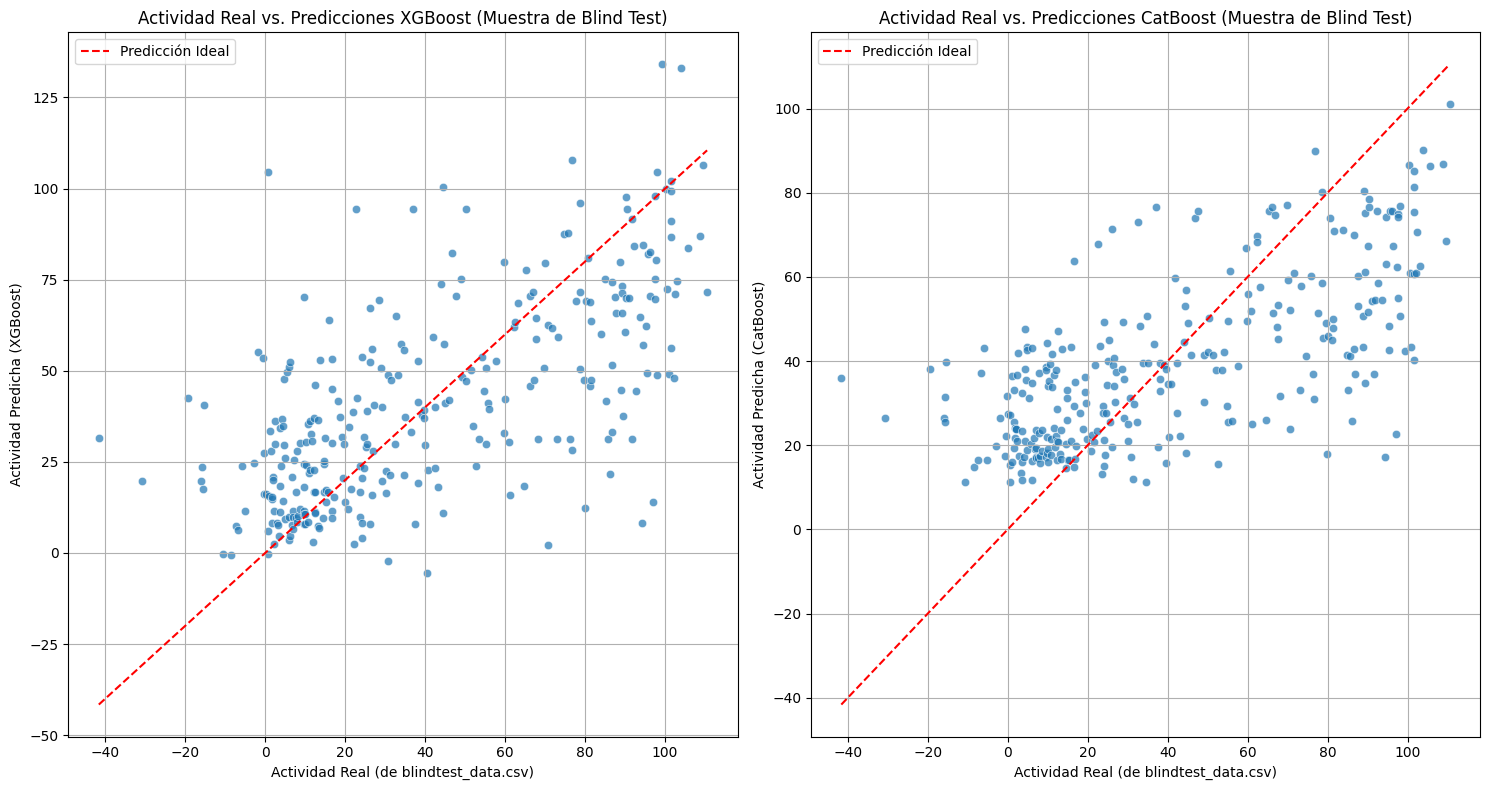


Resultados XGBoost en Blind Test (con valores de actividad disponibles):
  MAE: 20.2295
  RMSE: 26.9853
  RMSE (%): 66.50%
  R2: 0.4267

Resultados CatBoost en Blind Test (con valores de actividad disponibles):
  MAE: 21.1593
  RMSE: 26.3363
  RMSE (%): 64.90%
  R2: 0.4539


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Usar todos los resultados para visualización
sample_results = blind_test_results.dropna(subset=['activity_from_blindtest_csv']).sort_values(by='activity_from_blindtest_csv').reset_index(drop=True)

plt.figure(figsize=(15, 8))

# Graficar actividad real vs. XGBoost
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.scatterplot(x='activity_from_blindtest_csv', y='Predicted_Activity_XGBoost', data=sample_results, alpha=0.7)
plt.plot([sample_results['activity_from_blindtest_csv'].min(), sample_results['activity_from_blindtest_csv'].max()],
         [sample_results['activity_from_blindtest_csv'].min(), sample_results['activity_from_blindtest_csv'].max()],
         'r--', label='Predicción Ideal')
plt.title('Actividad Real vs. Predicciones XGBoost (Muestra de Blind Test)')
plt.xlabel('Actividad Real (de blindtest_data.csv)')
plt.ylabel('Actividad Predicha (XGBoost)')
plt.legend()
plt.grid(True)

# Graficar actividad real vs. CatBoost
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.scatterplot(x='activity_from_blindtest_csv', y='Predicted_Activity_CatBoost', data=sample_results, alpha=0.7)
plt.plot([sample_results['activity_from_blindtest_csv'].min(), sample_results['activity_from_blindtest_csv'].max()],
         [sample_results['activity_from_blindtest_csv'].min(), sample_results['activity_from_blindtest_csv'].max()],
         'r--', label='Predicción Ideal')
plt.title('Actividad Real vs. Predicciones CatBoost (Muestra de Blind Test)')
plt.xlabel('Actividad Real (de blindtest_data.csv)')
plt.ylabel('Actividad Predicha (CatBoost)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Calcular MAE, RMSE y R2 para el blind test (donde hay valores de actividad) ---

# Filtrar las filas donde 'activity_from_blindtest_csv' no es NaN
valid_blind_test_results = blind_test_results.dropna(subset=['activity_from_blindtest_csv']).copy()

if not valid_blind_test_results.empty:
    actual_activity = valid_blind_test_results['activity_from_blindtest_csv']

    # Métricas XGBoost
    xgb_blind_mae = mean_absolute_error(actual_activity, valid_blind_test_results['Predicted_Activity_XGBoost'])
    xgb_blind_rmse = np.sqrt(mean_squared_error(actual_activity, valid_blind_test_results['Predicted_Activity_XGBoost']))
    xgb_blind_r2 = r2_score(actual_activity, valid_blind_test_results['Predicted_Activity_XGBoost'])

    # Calcular RMSE como porcentaje para XGBoost
    mean_actual_activity = actual_activity.mean()
    xgb_blind_rmse_percentage = (xgb_blind_rmse / mean_actual_activity) * 100 if mean_actual_activity != 0 else 0

    print(f"\nResultados XGBoost en Blind Test (con valores de actividad disponibles):\n  MAE: {xgb_blind_mae:.4f}\n  RMSE: {xgb_blind_rmse:.4f}\n  RMSE (%): {xgb_blind_rmse_percentage:.2f}%\n  R2: {xgb_blind_r2:.4f}")

    # Métricas CatBoost
    cat_blind_mae = mean_absolute_error(actual_activity, valid_blind_test_results['Predicted_Activity_CatBoost'])
    cat_blind_rmse = np.sqrt(mean_squared_error(actual_activity, valid_blind_test_results['Predicted_Activity_CatBoost']))
    cat_blind_r2 = r2_score(actual_activity, valid_blind_test_results['Predicted_Activity_CatBoost'])

    # Calcular RMSE como porcentaje para CatBoost
    cat_blind_rmse_percentage = (cat_blind_rmse / mean_actual_activity) * 100 if mean_actual_activity != 0 else 0

    print(f"\nResultados CatBoost en Blind Test (con valores de actividad disponibles):\n  MAE: {cat_blind_mae:.4f}\n  RMSE: {cat_blind_rmse:.4f}\n  RMSE (%): {cat_blind_rmse_percentage:.2f}%\n  R2: {cat_blind_r2:.4f}")
else:
    print("No hay valores de actividad disponibles en el conjunto 'blind test' para calcular métricas.")

### Correlación entre Actividad Real y Predicciones de los Modelos



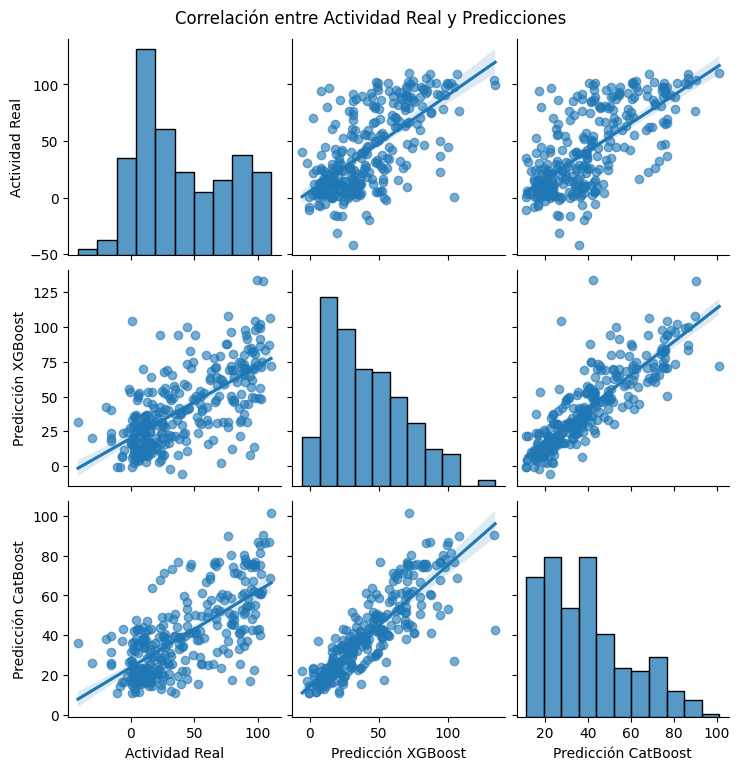

/tmp/ipykernel_391/1868072497.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='activity_from_blindtest_csv', y='Chemical', data=selected_chemicals.sort_values(by='activity_from_blindtest_csv', ascending=False), palette='coolwarm')


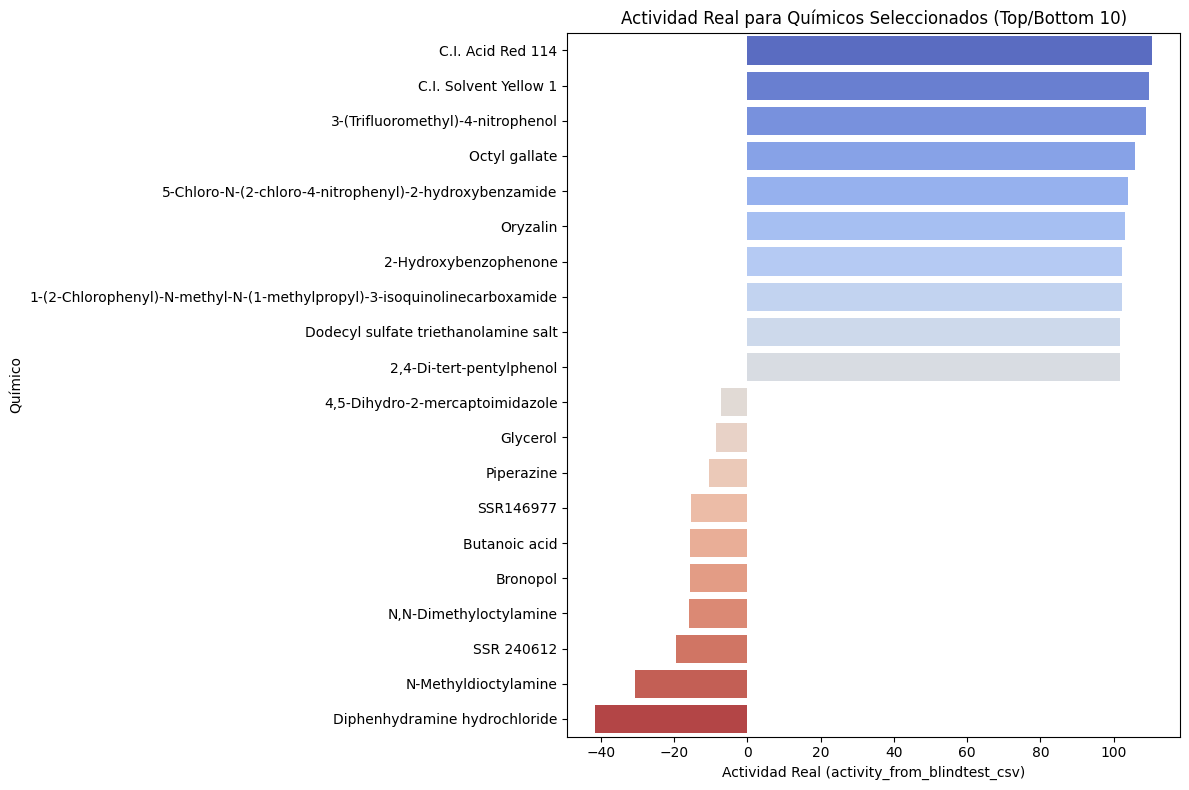

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico 1: Correlación entre Actividad Real y Predicciones de los Modelos
correlation_data = valid_blind_test_results[['activity_from_blindtest_csv', 'Predicted_Activity_XGBoost', 'Predicted_Activity_CatBoost']].rename(columns={
    'activity_from_blindtest_csv': 'Actividad Real',
    'Predicted_Activity_XGBoost': 'Predicción XGBoost',
    'Predicted_Activity_CatBoost': 'Predicción CatBoost'
})

sns.pairplot(correlation_data, kind='reg', plot_kws={'scatter_kws': {'alpha': 0.6}})
plt.suptitle('Correlación entre Actividad Real y Predicciones', y=1.02)
plt.show()

# Gráfico 2: Actividad por Químico para una muestra
# Para visualizar la relación entre el identificador del químico y su actividad,
# seleccionaremos los 10 químicos con mayor y 10 con menor actividad real para mayor claridad.
top_chemicals = valid_blind_test_results.sort_values(by='activity_from_blindtest_csv', ascending=False).head(10)
bottom_chemicals = valid_blind_test_results.sort_values(by='activity_from_blindtest_csv', ascending=True).head(10)
selected_chemicals = pd.concat([top_chemicals, bottom_chemicals])

plt.figure(figsize=(12, 8))
sns.barplot(x='activity_from_blindtest_csv', y='Chemical', data=selected_chemicals.sort_values(by='activity_from_blindtest_csv', ascending=False), palette='coolwarm')
plt.title('Actividad Real para Químicos Seleccionados (Top/Bottom 10)')
plt.xlabel('Actividad Real (activity_from_blindtest_csv)')
plt.ylabel('Químico')
plt.tight_layout()
plt.show()

### Importancia de las Características (Feature Importance)

La importancia de cada característica (bits de Morgan Fingerprints) en las predicciones de los modelos

/tmp/ipykernel_391/2736166995.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance_df, palette='viridis')


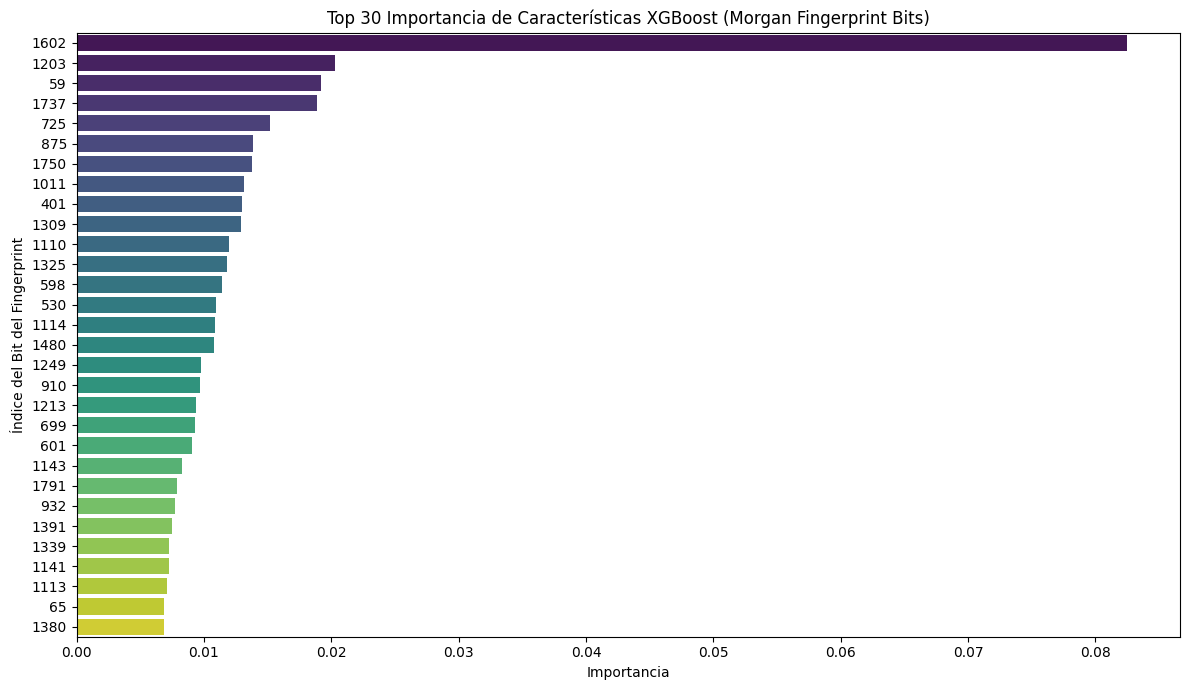

In [ ]:
plt.figure(figsize=(12, 7))

# Extraer la importancia de las características de XGBoost
xgb_importances = xgb_model.feature_importances_
feature_names = [str(i) for i in range(len(xgb_importances))]
xgb_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importances})
xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='Importance', ascending=False).head(30) # Mostrar el top 30

sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance_df, palette='viridis')
plt.title('Top 30 Importancia de Características XGBoost (Morgan Fingerprint Bits)')
plt.xlabel('Importancia')
plt.ylabel('Índice del Bit del Fingerprint')
plt.tight_layout()
plt.show()

/tmp/ipykernel_391/3080508498.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=cat_feature_importance_df, palette='magma')


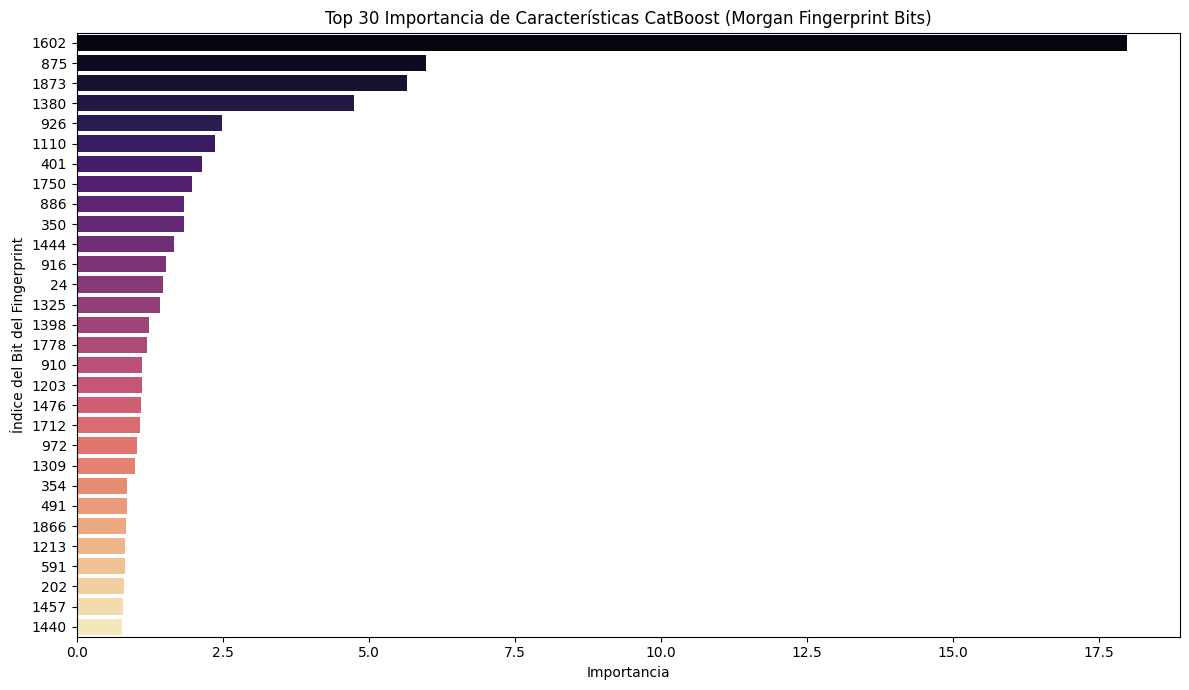

In [ ]:
plt.figure(figsize=(12, 7))

# Extraer la importancia de las características de CatBoost
cat_importances = cat_model.get_feature_importance()
feature_names = [str(i) for i in range(len(cat_importances))]
cat_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': cat_importances})
cat_feature_importance_df = cat_feature_importance_df.sort_values(by='Importance', ascending=False).head(30) # Mostrar el top 30

sns.barplot(x='Importance', y='Feature', data=cat_feature_importance_df, palette='magma')
plt.title('Top 30 Importancia de Características CatBoost (Morgan Fingerprint Bits)')
plt.xlabel('Importancia')
plt.ylabel('Índice del Bit del Fingerprint')
plt.tight_layout()
plt.show()

### Identificación de Moléculas con el Bit 1602 Activo

Como no se puede visualizar directamente la subestructura asociada al bit 1602 de forma aislada, se identifican y listan moléculas donde este bit está activo. Al examinar visualmente las estructuras de varias de estas moléculas, se puede inferir qué tipo de motivo químico común podría estar representado por este bit.

Se muestran los SMILES de las primeras 10 moléculas para las cuales el bit 1602 está activo.

Se encontraron 120 moléculas con el bit 1602 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 1602 activo:
1. SMILES: Oc1cccc2ccccc12 - Chemical: 1-Naphthol
2. SMILES: Oc1ccccc1O - Chemical: 1,​2-​Benzenediol
3. SMILES: CC12CCC3c4ccc(O)cc4CCC3C1CCC2O - Chemical: 17alpha-Estradiol
4. SMILES: C#CC1(O)CCC2C3CCc4cc(O)ccc4C3CCC21C - Chemical: 17alpha-Ethinylestradiol
5. SMILES: CC12CCC3c4ccc(O)cc4CCC3C1CCC2O - Chemical: 17beta-Estradiol
6. SMILES: O=C(CBr)c1ccc(O)cc1 - Chemical: 2-Bromo-4-hydroxyacetophenone
7. SMILES: Oc1ccc(-c2ccccc2)cc1Cl - Chemical: 2-Chloro-4-phenylphenol
8. SMILES: CCc1ccccc1O - Chemical: 2-Ethylphenol
9. SMILES: COc1ccc(C(=O)c2ccccc2)c(O)c1 - Chemical: 2-Hydroxy-4-methoxybenzophenone
10. SMILES: COc1ccccc1O - Chemical: 2-Methoxyphenol

Visualización de las primeras 10 moléculas con el bit 1602 activo:


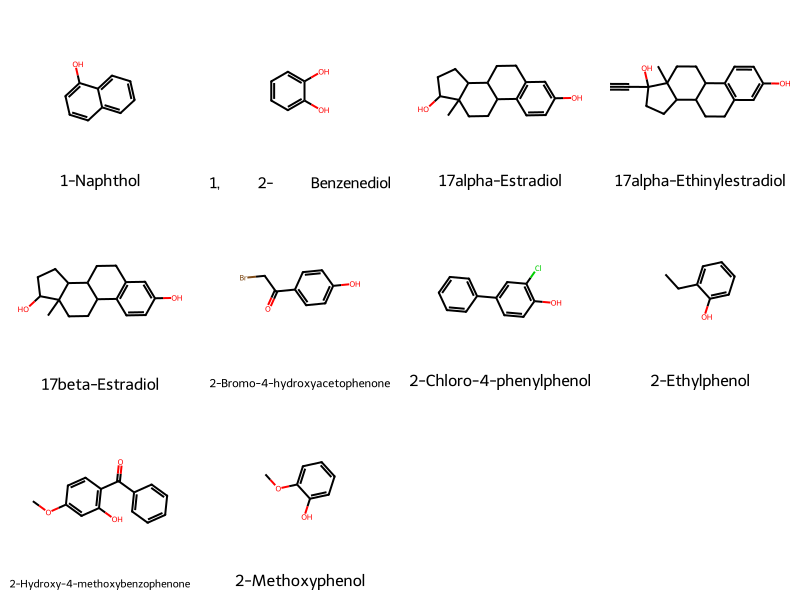

In [ ]:
from rdkit.Chem.Draw import MolsToGridImage
from rdkit import Chem

# Filtrar las moléculas que tienen el bit 1602 activo en training_features_rdkit
molecules_with_bit_1602 = training_features_rdkit[training_features_rdkit[1602] == 1]

if not molecules_with_bit_1602.empty:
    # Obtener los índices originales de estas moléculas en training_data_reindexed
    original_indices_with_bit = molecules_with_bit_1602.index

    # Recuperar los SMILES correspondientes y los nombres químicos para las primeras 10
    smiles_for_bit_1602_head = training_data_reindexed.loc[original_indices_with_bit, 'pubchem_smiles_cleaned'].head(10)
    chemicals_for_bit_1602_head = training_data_reindexed.loc[original_indices_with_bit, 'Chemical'].head(10)

    print(f"Se encontraron {len(original_indices_with_bit)} moléculas con el bit 1602 activo.\n")
    print("SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 1602 activo:")

    mols = []
    legends = []
    for i, smiles in enumerate(smiles_for_bit_1602_head):
        chemical_name = chemicals_for_bit_1602_head.iloc[i]
        print(f"{i+1}. SMILES: {smiles} - Chemical: {chemical_name}")
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            mols.append(mol)
            legends.append(chemical_name) # Usar el nombre químico como leyenda

    # Visualizar las moléculas
    if mols:
        print("\nVisualización de las primeras 10 moléculas con el bit 1602 activo:")
        display(MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=legends))

else:
    print("No se encontraron moléculas con el bit 1602 activo en el conjunto de entrenamiento.")

### Visualización de Moléculas para los Siguientes Bits Importantes de XGBoost

Se visualizan las primeras 10 moléculas con los 4 bits más importantes para el modelo XGBoost (después del bit 1602) que son: 1203, 59, 1737 y 725. Para cada bit, se listan los SMILES y los nombres químicos, y se muestran las estructuras.


--- Analizando el Bit: 1203 (XGBoost) ---
Se encontraron 18 moléculas con el bit 1203 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 1203 activo:
1. SMILES: CC1=NN(c2ccc(S(=O)(=O)[O-])cc2)C(=O)C1N=Nc1ccccc1.[Na+] - Chemical: C.I. Acid Yellow 11, sodium salt
2. SMILES: CC1=NN(c2cc(Cl)c(S(=O)(=O)[O-])cc2Cl)C(=O)C1N=Nc1ccc(S(=O)(=O)[O-])cc1.[Na+].[Na+] - Chemical: C.I. Acid Yellow 17, disodium salt
3. SMILES: CC1=NN(c2cc(S(=O)(=O)[O-])ccc2Cl)C(=O)C1N=Nc1ccccc1.[Na+] - Chemical: C.I. Acid Yellow 34, monosodium salt
4. SMILES: CCOP(=S)(OCC)OC(Cl)C(Cl)(Cl)Cl - Chemical: Chlorethoxyfos
5. SMILES: CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl - Chemical: Chlorpyrifos
6. SMILES: CCOP(=O)(OCC)Oc1nc(Cl)c(Cl)cc1Cl - Chemical: Chlorpyrifos oxon
7. SMILES: CCOP(=S)(OCC)Oc1cc(C)nc(C(C)C)n1 - Chemical: Diazinon
8. SMILES: CCCOC(=O)c1ccc(C(=O)OCCC)nc1 - Chemical: Dipropyl 2,5-pyridinedicarboxylate
9. SMILES: CCOP(=S)(Oc1ccc([N+](=O)[O-])cc1)c1ccccc1 - Chemical: EPN
10. SMILES: CCOP(=S)(

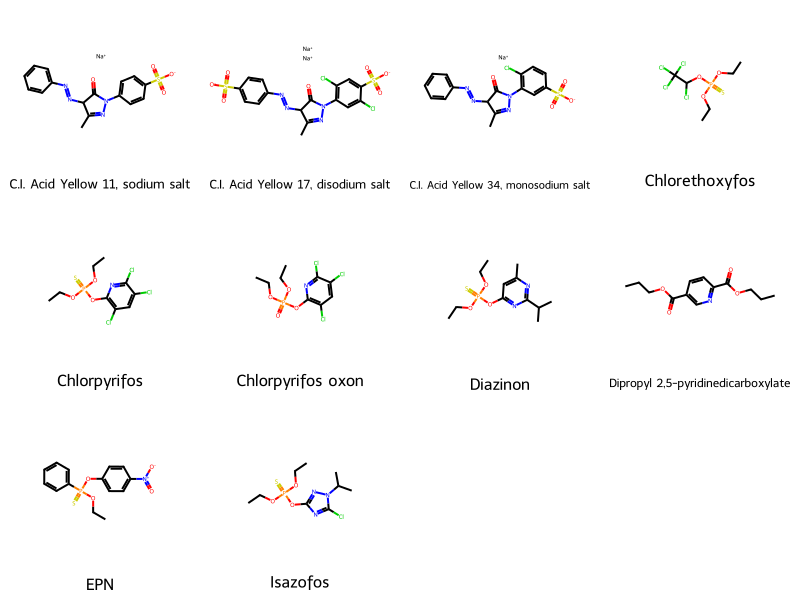


--- Analizando el Bit: 59 (XGBoost) ---
Se encontraron 17 moléculas con el bit 59 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 59 activo:
1. SMILES: OCCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F - Chemical: 2-(Perfluorohexyl)ethanol
2. SMILES: C=C(C)C(=O)OCCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F - Chemical: 2-(Perfluorohexyl)ethyl methacrylate
3. SMILES: N.O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F - Chemical: Ammonium perfluorooctanoate
4. SMILES: Oc1ccc(C(c2ccc(O)cc2)(C(F)(F)F)C(F)(F)F)cc1 - Chemical: Bisphenol AF
5. SMILES: OCCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F - Chemical: Fluorotelomer alcohol 8:2
6. SMILES: CCNS(=O)(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F - Chemical: N-Ethylperfluorooctanesulfonamide
7. SMILES: O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F - Chemical: Perfluorodecanoic acid
8. SMILES: O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F - Chemical: 

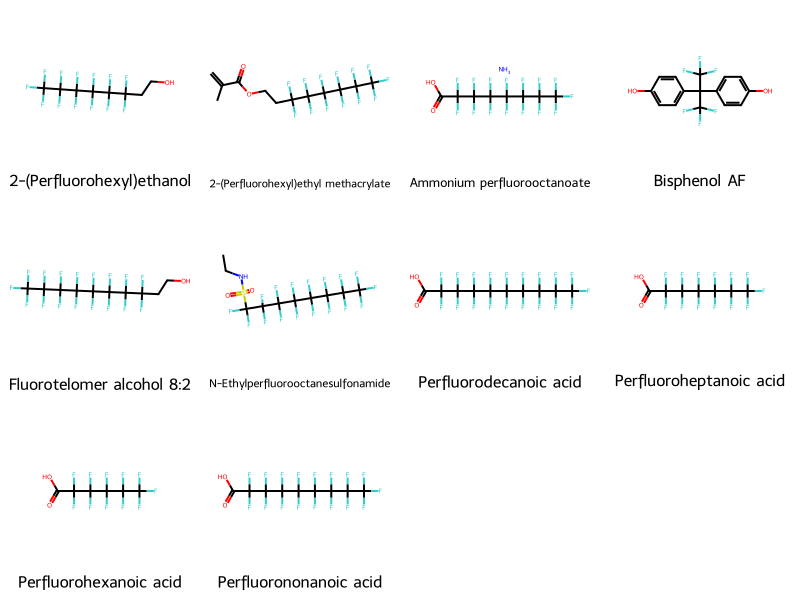


--- Analizando el Bit: 1737 (XGBoost) ---
Se encontraron 38 moléculas con el bit 1737 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 1737 activo:
1. SMILES: Cc1cccc(Nc2cc(Cl)nc(SCC(=O)O)n2)c1C - Chemical: [4-Chloro-6-(2,3-xylidino)-2-pyrimidinylthio]acetic acid
2. SMILES: COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1 - Chemical: 1-(p-Chlorobenzoyl)-5-methoxy-2-methyl-Indole-3-acetic acid
3. SMILES: O=C(O)Cc1cccc2ccccc12 - Chemical: 1-Naphthaleneacetic acid
4. SMILES: C=CCCCCCCCCC(=O)O - Chemical: 10-Undecenoic acid
5. SMILES: Cc1cc(Cl)ccc1OCC(=O)O - Chemical: 2-(4-Chloro-2-methylphenoxy)acetic acid
6. SMILES: O=C(O)COc1ccc(Cl)cc1Cl - Chemical: 2,4-Dichlorophenoxyacetic acid
7. SMILES: O=C(O)CCCOc1ccc(Cl)cc1Cl - Chemical: 2,4-Dichlorophenoxybutyric acid
8. SMILES: O=C(O)COc1cc(Cl)c(Cl)cc1Cl - Chemical: 2,4,5-Trichlorophenoxyacetic acid
9. SMILES: O=C(O)COc1ccc(Cl)cc1 - Chemical: 4-Chlorophenoxyacetic acid
10. SMILES: CC(CCC(=O)O)(c1ccc(O)cc1)c1ccc(O)cc1 - C

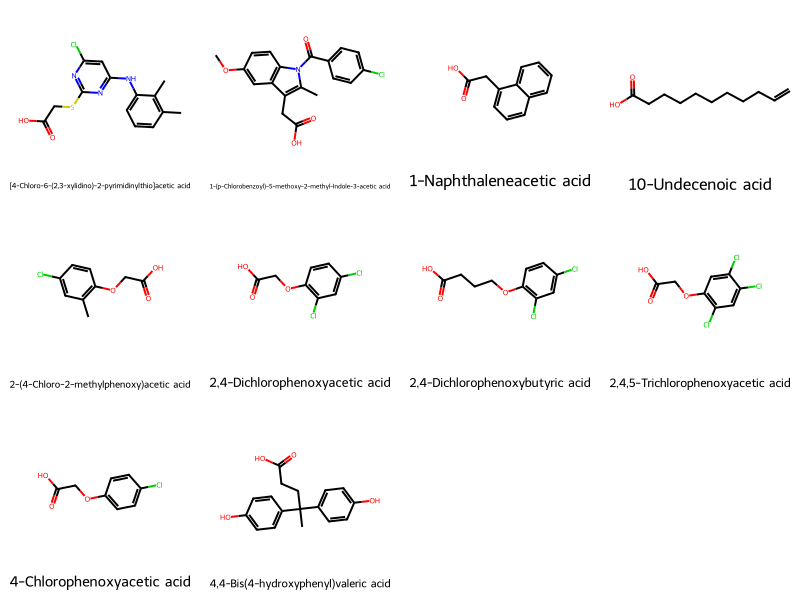


--- Analizando el Bit: 725 (XGBoost) ---
Se encontraron 41 moléculas con el bit 725 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 725 activo:
1. SMILES: CCC(C)=NO - Chemical: 2-Butanone oxime
2. SMILES: Cc1cn(C2CC(N=[N+]=[N-])C(CO)O2)c(=O)[nH]c1=O - Chemical: 3'-Azido-3'-deoxythymidine
3. SMILES: O=Nc1ccc(Nc2ccccc2)cc1 - Chemical: 4-Nitrosodiphenylamine
4. SMILES: Nc1ccc2cc(S(=O)(=O)[O-])cc(O)c2c1N=Nc1ccccc1C(F)(F)F.[Na+] - Chemical: Acid Red 337
5. SMILES: CSC(C)(C)C=NO - Chemical: Aldicarb oxime
6. SMILES: CNC(=O)ON=CC(C)(C)S(C)(=O)=O - Chemical: Aldicarb sulfone
7. SMILES: CNC(=O)ON=CC(C)(C)[S+](C)[O-] - Chemical: Aldicarb sulfoxide
8. SMILES: COc1cc(S(=O)(=O)[O-])c(C)cc1N=Nc1c(O)ccc2cc(S(=O)(=O)[O-])ccc12.[Na+].[Na+] - Chemical: Allura Red C.I.16035
9. SMILES: Cc1ccc(N=CN(C)C=Nc2ccc(C)cc2C)c(C)c1 - Chemical: Amitraz
10. SMILES: CCN=C1C=CC(=C(c2ccc(N(CC)CC)cc2)c2ccc(N(CC)CC)cc2)c2ccccc21.Cl - Chemical: Basic Blue 7

Visualización de las primeras 10 molé

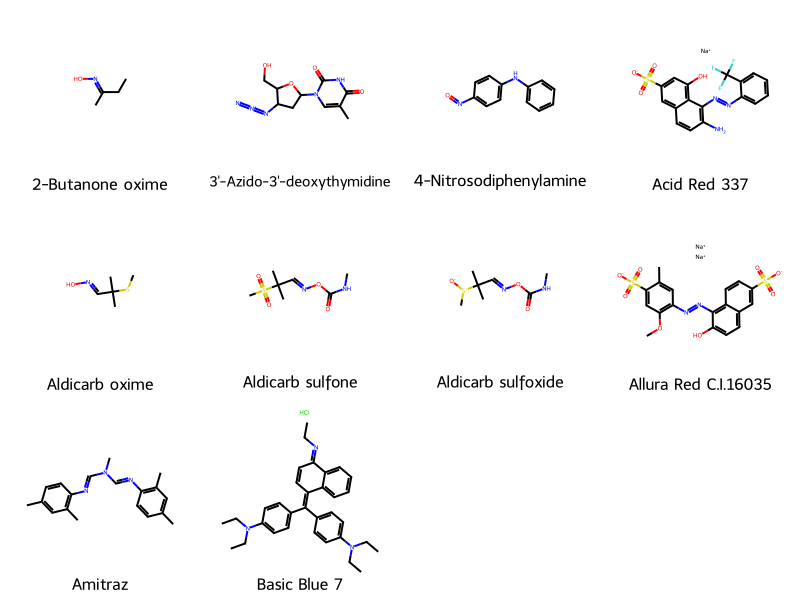

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage

xgb_top_bits = [1203, 59, 1737, 725]

for bit_to_visualize in xgb_top_bits:
    print(f"\n--- Analizando el Bit: {bit_to_visualize} (XGBoost) ---")
    molecules_with_current_bit = training_features_rdkit[training_features_rdkit[bit_to_visualize] == 1]

    if not molecules_with_current_bit.empty:
        original_indices_with_bit = molecules_with_current_bit.index
        smiles_for_bit_head = training_data_reindexed.loc[original_indices_with_bit, 'pubchem_smiles_cleaned'].head(10)
        chemicals_for_bit_head = training_data_reindexed.loc[original_indices_with_bit, 'Chemical'].head(10)

        print(f"Se encontraron {len(original_indices_with_bit)} moléculas con el bit {bit_to_visualize} activo.\n")
        print(f"SMILES y Nombres Químicos de las primeras 10 moléculas con el bit {bit_to_visualize} activo:")

        mols = []
        legends = []
        for i, smiles in enumerate(smiles_for_bit_head):
            chemical_name = chemicals_for_bit_head.iloc[i]
            print(f"{i+1}. SMILES: {smiles} - Chemical: {chemical_name}")
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                mols.append(mol)
                legends.append(chemical_name)

        if mols:
            print(f"\nVisualización de las primeras 10 moléculas con el bit {bit_to_visualize} activo:")
            display(MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=legends))

    else:
        print(f"No se encontraron moléculas con el bit {bit_to_visualize} activo en el conjunto de entrenamiento.")

### Visualización de Moléculas para los Siguientes Bits Importantes de CatBoost

Se repite el proceso para los 4 bits más importantes del modelo CatBoost (después del bit 1602), que son: 875, 1873, 1380 y 926. Para cada bit, se listan los SMILES y los nombres químicos, y se muestran las estructuras.


--- Analizando el Bit: 875 (CatBoost) ---
Se encontraron 242 moléculas con el bit 875 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 875 activo:
1. SMILES: COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1 - Chemical: (+-)-Diclofop-methyl
2. SMILES: Cc1cc(C)n(CO)n1 - Chemical: (3,5-Dimethyl-1H-pyrazol-1-yl)methanol
3. SMILES: Cc1cccc(Nc2cc(Cl)nc(SCC(=O)O)n2)c1C - Chemical: [4-Chloro-6-(2,3-xylidino)-2-pyrimidinylthio]acetic acid
4. SMILES: COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1 - Chemical: 1-(p-Chlorobenzoyl)-5-methoxy-2-methyl-Indole-3-acetic acid
5. SMILES: Cn1cc(-c2ccccc2)c(=O)c(-c2cccc(C(F)(F)F)c2)c1 - Chemical: 1-Methyl-3-phenyl-5-(3-(trifluoromethyl)phenyl)-4-pyridone
6. SMILES: Cc1ccc(C(C)c2ccc(C)c(C)c2)cc1C - Chemical: 1,1-Bis(3,4-dimethylphenyl)ethane
7. SMILES: FC(F)(F)c1ccc(Cl)c(Cl)c1 - Chemical: 1,2-Dichloro-4-(trifluoromethyl)benzene
8. SMILES: Clc1ccc(Cl)c(Cl)c1 - Chemical: 1,2,4-Trichlorobenzene
9. SMILES: Cc1ccc(C)c(C)c1 - Chemical: 1,2,4-Trimet

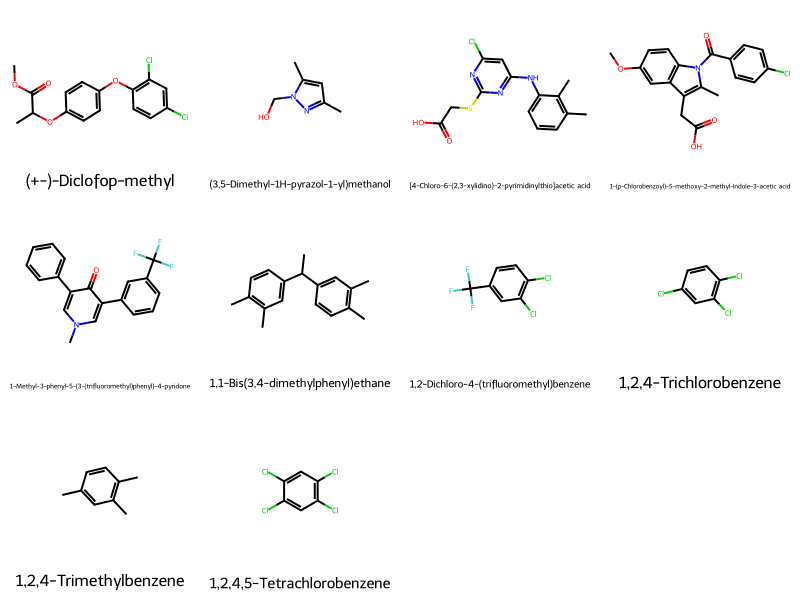


--- Analizando el Bit: 1873 (CatBoost) ---
Se encontraron 602 moléculas con el bit 1873 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 1873 activo:
1. SMILES: COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1 - Chemical: (+-)-Diclofop-methyl
2. SMILES: Cc1cc(C)n(CO)n1 - Chemical: (3,5-Dimethyl-1H-pyrazol-1-yl)methanol
3. SMILES: C=C(C)C(=O)OCCOC1CC2CC1C1C=CCC21 - Chemical: (Dicyclopentadienyloxy)ethyl methacrylate
4. SMILES: Cc1cccc(Nc2cc(Cl)nc(SCC(=O)O)n2)c1C - Chemical: [4-Chloro-6-(2,3-xylidino)-2-pyrimidinylthio]acetic acid
5. SMILES: Clc1ccc(C(c2ccccc2Cl)C(Cl)Cl)cc1 - Chemical: 1-(2-Chlorophenyl)-1-(4-chlorophenyl)-2,2-dichloroethane
6. SMILES: COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1 - Chemical: 1-(p-Chlorobenzoyl)-5-methoxy-2-methyl-Indole-3-acetic acid
7. SMILES: FC(F)(F)c1ccc(Cl)cc1 - Chemical: 1-Chloro-4-(trifluoromethyl)benzene
8. SMILES: O=[N+]([O-])c1ccc(Cl)cc1 - Chemical: 1-Chloro-4-nitrobenzene
9. SMILES: Cn1cc(-c2ccccc2)c(=O)c(-c2cccc(C(F)(F)F)c2)

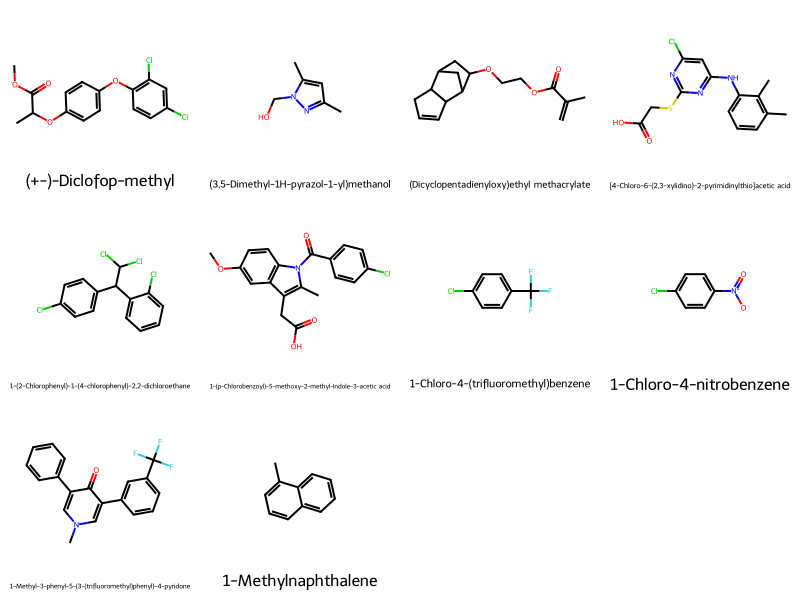


--- Analizando el Bit: 1380 (CatBoost) ---
Se encontraron 673 moléculas con el bit 1380 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 1380 activo:
1. SMILES: C=C1CCC2CC1C2(C)C - Chemical: (-)-beta-Pinene
2. SMILES: COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1 - Chemical: (+-)-Diclofop-methyl
3. SMILES: CCCCCCCCCC=CCC1CC(=O)OC1=O - Chemical: (2-Dodecenyl)succinic anhydride
4. SMILES: Cc1cc(C)n(CO)n1 - Chemical: (3,5-Dimethyl-1H-pyrazol-1-yl)methanol
5. SMILES: Cc1cccc(Nc2cc(Cl)nc(SCC(=O)O)n2)c1C - Chemical: [4-Chloro-6-(2,3-xylidino)-2-pyrimidinylthio]acetic acid
6. SMILES: Clc1ccc(C(c2ccccc2Cl)C(Cl)Cl)cc1 - Chemical: 1-(2-Chlorophenyl)-1-(4-chlorophenyl)-2,2-dichloroethane
7. SMILES: CC1(C)C(=O)NC(=O)N1CO - Chemical: 1-(Hydroxymethyl)-5,5-dimethylhydantoin
8. SMILES: COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1 - Chemical: 1-(p-Chlorobenzoyl)-5-methoxy-2-methyl-Indole-3-acetic acid
9. SMILES: CC1(C)C(=O)N(Cl)C(=O)N1Br - Chemical: 1-Bromo-3-chloro-5,5-dimethylhy

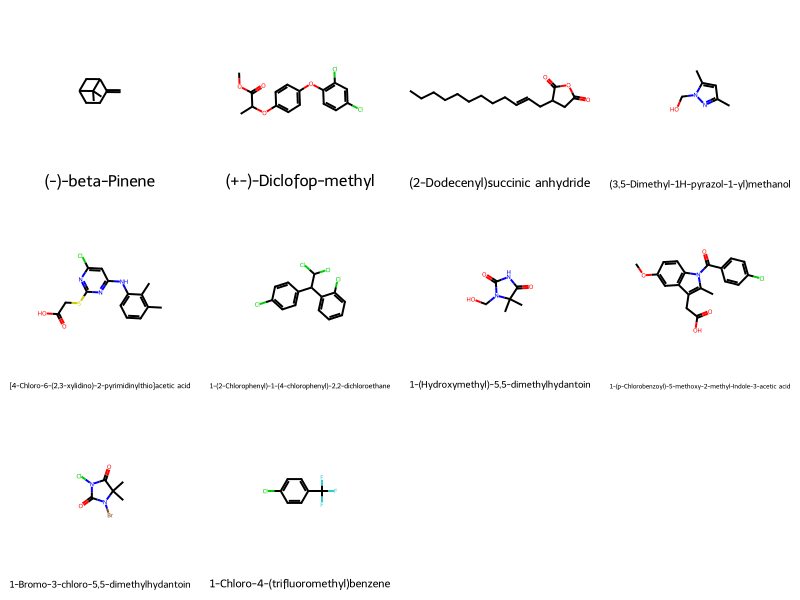


--- Analizando el Bit: 926 (CatBoost) ---
Se encontraron 192 moléculas con el bit 926 activo.

SMILES y Nombres Químicos de las primeras 10 moléculas con el bit 926 activo:
1. SMILES: C=C1CCC2CC1C2(C)C - Chemical: (-)-beta-Pinene
2. SMILES: CC(=O)OC1CC2CCC1(C)C2(C)C - Chemical: (±)-Bornyl acetate
3. SMILES: CCCCCCCCCC=CCC1CC(=O)OC1=O - Chemical: (2-Dodecenyl)succinic anhydride
4. SMILES: C=C(C)C(=O)OCCOC1CC2CC1C1C=CCC21 - Chemical: (Dicyclopentadienyloxy)ethyl methacrylate
5. SMILES: CCCCCCCCCCCCN1CCCC1=O - Chemical: 1-Dodecyl-2-pyrrolidinone
6. SMILES: CCC(C)(C)C1CCC(OC)CC1 - Chemical: 1-Methoxy-4-tert-pentylcyclohexane
7. SMILES: CCCCCCCCN1CCCC1=O - Chemical: 1-Octyl-2-pyrrolidone
8. SMILES: O=C1NC(=O)C2CC=CCC12 - Chemical: 1,2,3,6-Tetrahydrophthalimide
9. SMILES: C1=CCC=C1 - Chemical: 1,3-Cyclopentadiene
10. SMILES: Cl.Clc1cc(Cl)c2c(c1)N=C1CCCCCN1C2 - Chemical: 1,3-Dichloro-6,7,8,9,10,12-hexahydroazepino[2,1-b]quinazoline hydrochloride (1:1)

Visualización de las primeras 10 molécu

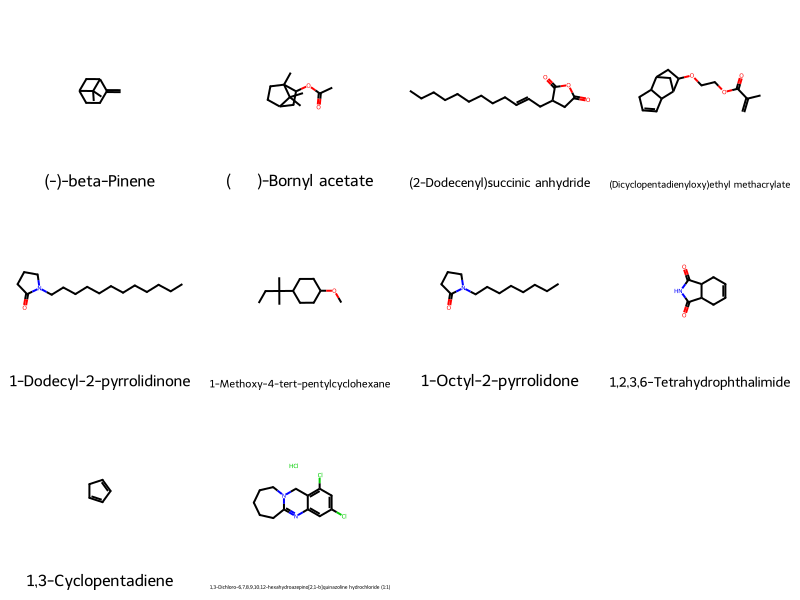

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage

catboost_top_bits = [875, 1873, 1380, 926]

for bit_to_visualize in catboost_top_bits:
    print(f"\n--- Analizando el Bit: {bit_to_visualize} (CatBoost) ---")
    molecules_with_current_bit = training_features_rdkit[training_features_rdkit[bit_to_visualize] == 1]

    if not molecules_with_current_bit.empty:
        original_indices_with_bit = molecules_with_current_bit.index
        smiles_for_bit_head = training_data_reindexed.loc[original_indices_with_bit, 'pubchem_smiles_cleaned'].head(10)
        chemicals_for_bit_head = training_data_reindexed.loc[original_indices_with_bit, 'Chemical'].head(10)

        print(f"Se encontraron {len(original_indices_with_bit)} moléculas con el bit {bit_to_visualize} activo.\n")
        print(f"SMILES y Nombres Químicos de las primeras 10 moléculas con el bit {bit_to_visualize} activo:")

        mols = []
        legends = []
        for i, smiles in enumerate(smiles_for_bit_head):
            chemical_name = chemicals_for_bit_head.iloc[i]
            print(f"{i+1}. SMILES: {smiles} - Chemical: {chemical_name}")
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                mols.append(mol)
                legends.append(chemical_name)

        if mols:
            print(f"\nVisualización de las primeras 10 moléculas con el bit {bit_to_visualize} activo:")
            display(MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=legends))

    else:
        print(f"No se encontraron moléculas con el bit {bit_to_visualize} activo en el conjunto de entrenamiento.")